# Day 1: Data Ingestion Pipeline - GEE Streaming (No Massive Downloads!)
## Sentinel-2 Super-Resolution Project

### 🎯 Strategy: API Streaming - NO 107GB Downloads!

**Why GEE Streaming Wins for 72-Hour Hackathon:**
- ✅ **Zero massive downloads** - Fetch 256×256 patches on-demand via API
- ✅ **Start training immediately** - No waiting for downloads
- ✅ **Flexible** - Query any location (Delhi, Kanpur, Mumbai, etc.)
- ✅ **Fresh data** - Real-time Sentinel-2 access
- ✅ **Synthetic HR** - Create 4x pairs by downsampling (standard practice)

**WorldStrat Note:**
- Reference dataset (~107 GB) - Great for research but NOT needed for hackathon
- Our GEE approach follows same principle: LR (10m) → HR target (synthetic 2.5m)

### Goals:
1. ✅ Authenticate Google Earth Engine
2. ✅ Stream Sentinel-2 patches via API (256×256 HR)
3. ✅ Create synthetic LR/HR pairs (4x downsampling)
4. ✅ Setup PyTorch DataLoader with on-demand fetching
5. ✅ Save only ~1000 training patches (~200MB total)

In [4]:
# Install required packages (use %pip for better compatibility)
%pip install earthengine-api rasterio albumentations -q

In [3]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import ee

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
import ee
ee.Authenticate()

In [6]:
# Initialize GEE with project
ee.Initialize(project='klymohackathon')
print("✅ Connected to GEE: projectklymo")
print("🌍 Ready to stream Sentinel-2 patches!")

✅ Connected to GEE: projectklymo
🌍 Ready to stream Sentinel-2 patches!


In [7]:
import ee

# Authenticate (opens browser - one-time only)
try:
    ee.Authenticate()
    print("✅ GEE authenticated successfully!")
except Exception as e:
    print(f"⚠️ Already authenticated: {e}")

✅ GEE authenticated successfully!


## Step 2: Authenticate Google Earth Engine (Secondary Source)

## Step 1: Authenticate Google Earth Engine

In [8]:
!git clone https://github.com/chandan-l-s-me/Klymo_hackathon_


Cloning into 'Klymo_hackathon_'...
remote: Enumerating objects: 278, done.
remote: Counting objects: 100% (278/278), done.
remote: Compressing objects: 100% (276/276), done.
remote: Total 278 (delta 3), reused 273 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (278/278), 25.85 MiB | 38.31 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [9]:
!pwd
!ls
!ls Klymo_hackathon_/src/data



/content
Klymo_hackathon_  sample_data
augmentation.py  gee_fetcher.py  preprocessing.py
dataset.py	 __init__.py	 worldstrat_loader.py


## Step 2: Test GEE Connection - Fetch Single Patch

In [10]:
import os
import sys
import importlib.util

# Get project root - notebook is in projectklymo/notebooks, so go up one level
notebook_dir = os.getcwd()
project_root = "/content/Klymo_hackathon_"
# Go up to projectklymo

# Reload module to get latest changes
gee_fetcher_path = os.path.join(project_root, "src", "data", "gee_fetcher.py")

spec = importlib.util.spec_from_file_location("gee_fetcher", gee_fetcher_path)
gee_module = importlib.util.module_from_spec(spec)
sys.modules['gee_fetcher'] = gee_module
spec.loader.exec_module(gee_module)

# Initialize fetcher
config_path = os.path.join(project_root, 'config.yaml')
fetcher = gee_module.GEEFetcher(config_path)
print("✅ GEEFetcher reloaded with fixed dataset")

✅ Connected to GEE project: projectklymo
✅ GEEFetcher reloaded with fixed dataset


In [11]:
# Initialize GEE with project
ee.Initialize(project='klymohackathon')
print("✅ Connected to GEE: projectklymo")
print("🌍 Ready to stream Sentinel-2 patches!")

✅ Connected to GEE: projectklymo
🌍 Ready to stream Sentinel-2 patches!


📍 Fetching Delhi test patch...
📍 Fetching Delhi (28.6139, 77.209)
✅ Patch shape: (884, 1000, 3)
✅ Value range: [19, 255]


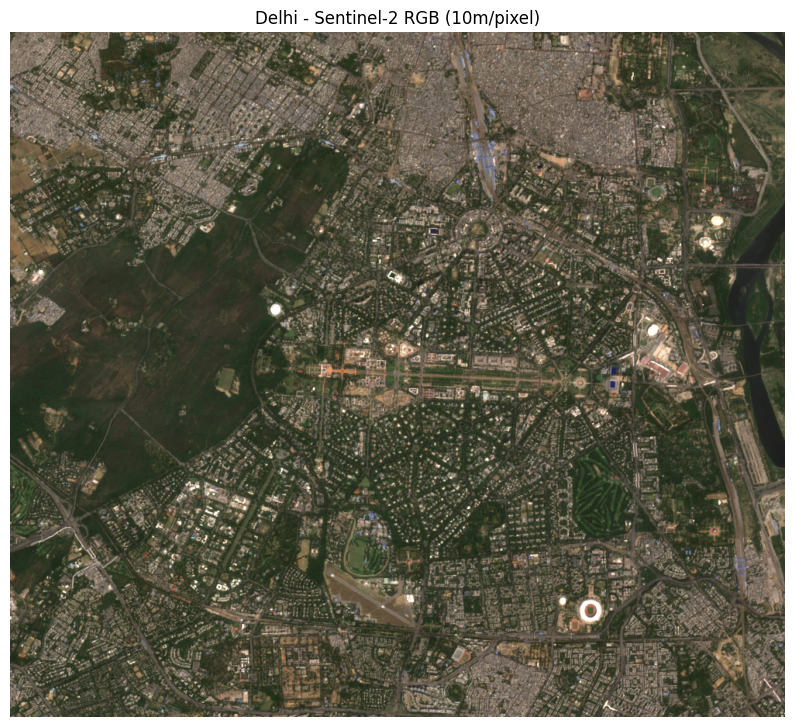

In [12]:
# Fetch a test patch (Delhi)
print("📍 Fetching Delhi test patch...")
delhi_patch = fetcher.fetch_specific_location('Delhi')

if delhi_patch is not None:
    print(f"✅ Patch shape: {delhi_patch.shape}")
    print(f"✅ Value range: [{delhi_patch.min()}, {delhi_patch.max()}]")

    # Visualize
    plt.figure(figsize=(10, 10))
    plt.imshow(delhi_patch)
    plt.title('Delhi - Sentinel-2 RGB (10m/pixel)')
    plt.axis('off')
    plt.show()

## Step 3: Create LR/HR Pair (Synthetic Degradation)

In [13]:
# Load preprocessing module
preprocessing_path = os.path.join(project_root, "src", "data", "preprocessing.py")
spec = importlib.util.spec_from_file_location("preprocessing", preprocessing_path)
preprocessing_module = importlib.util.module_from_spec(spec)
sys.modules['preprocessing'] = preprocessing_module
spec.loader.exec_module(preprocessing_module)

preprocessor = preprocessing_module.DataPreprocessor(config_path)
print("✅ DataPreprocessor loaded")

✅ DataPreprocessor loaded


LR shape: (221, 250, 3)
HR shape: (884, 1000, 3)


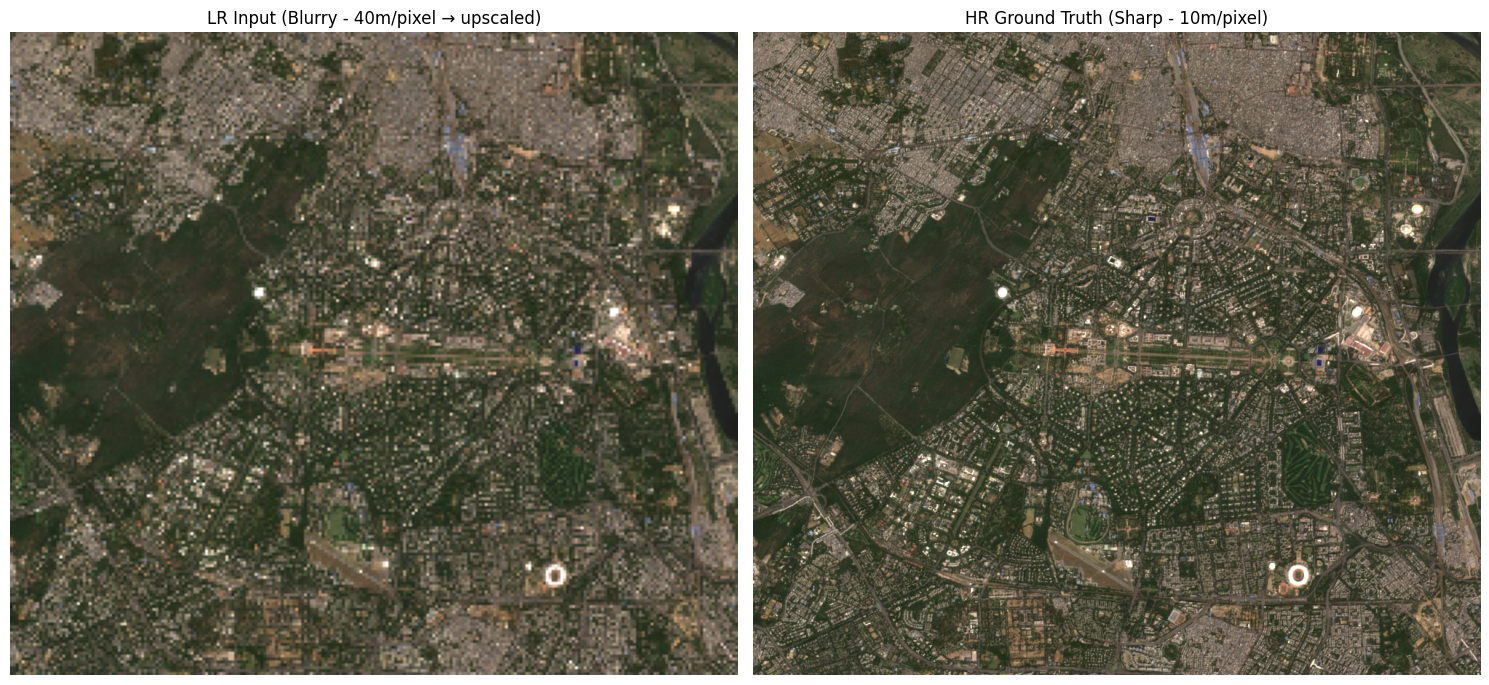

In [14]:
# Create LR/HR pair from Delhi patch
lr_patch, hr_patch = preprocessor.create_lr_hr_pair(delhi_patch, scale=4)

print(f"LR shape: {lr_patch.shape}")
print(f"HR shape: {hr_patch.shape}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(lr_patch)
axes[0].set_title('LR Input (Blurry - 40m/pixel → upscaled)')
axes[0].axis('off')

axes[1].imshow(hr_patch)
axes[1].set_title('HR Ground Truth (Sharp - 10m/pixel)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 4: Fetch Training Dataset (Small Test - 50 samples)

In [16]:
# Fetch 50 random patches from India
# NOTE: This will take ~10-15 minutes due to API rate limits
# For full dataset (1000 samples), run overnight or in Colab

num_samples = 1000  # Start small for testing
save_dir = '../data/raw_test'

print(f"🌍 Fetching {num_samples} random Sentinel-2 patches...")
print("⏳ This may take 10-15 minutes...\n")

successful = fetcher.fetch_dataset(
    num_samples=num_samples,
    save_dir=save_dir,
    region='india'
)

print(f"\n✅ Fetched {successful} patches successfully!")

🌍 Fetching 1000 random Sentinel-2 patches...
⏳ This may take 10-15 minutes...

🌍 Fetching 1000 Sentinel-2 patches from india...


  1%|          | 11/1000 [00:36<51:24,  3.12s/it]

⚠️ No images found for (14.7512, 86.9964)


  1%|          | 12/1000 [00:40<59:06,  3.59s/it]

⚠️ No images found for (18.0192, 90.3548)


...

⚠️ No images found for (17.1431, 68.7338)


 98%|█████████▊| 982/1000 [1:13:07<00:53,  2.99s/it]

⚠️ No images found for (8.1080, 87.0926)


100%|██████████| 1000/1000 [1:14:03<00:00,  4.44s/it]


✅ Successfully fetched: 1000 patches
❌ Failed: 190 patches
📁 Saved to: ../data/raw_test

✅ Fetched 1000 patches successfully!


## Step 5: Process Dataset (Create LR/HR Pairs)

In [17]:
# Process the fetched data
input_dir = '../data/raw_test'
output_dir = '../data/processed_test'

print("⚙️ Processing dataset: Creating LR/HR pairs...")

patch_count = preprocessor.process_dataset(
    input_dir=input_dir,
    output_dir=output_dir,
    split='train'
)

print(f"\n✅ Created {patch_count} LR/HR patch pairs!")

⚙️ Processing dataset: Creating LR/HR pairs...
📦 Processing 1001 images for train set...


100%|██████████| 1001/1001 [00:59<00:00, 16.85it/s]

✅ Created 1001 LR/HR patch pairs
📁 Saved to ../data/processed_test/train/

✅ Created 1001 LR/HR patch pairs!


## Step 6: Setup PyTorch DataLoader

In [22]:
import torch
import importlib.util

# Load dataset module
dataset_path = os.path.join(project_root, "src", "data", "dataset.py")
spec = importlib.util.spec_from_file_location("dataset", dataset_path)
dataset_module = importlib.util.module_from_spec(spec)
sys.modules['dataset'] = dataset_module
spec.loader.exec_module(dataset_module)

# Load augmentation module
augmentation_path = os.path.join(project_root, "src", "data", "augmentation.py")
spec = importlib.util.spec_from_file_location("augmentation", augmentation_path)
augmentation_module = importlib.util.module_from_spec(spec)
sys.modules['augmentation'] = augmentation_module
spec.loader.exec_module(augmentation_module)

get_dataloader = dataset_module.get_dataloader
visualize_batch = dataset_module.visualize_batch

# Modified get_training_augmentation to allow different image sizes
def get_training_augmentation():
    return augmentation_module.A.Compose(
        [
            augmentation_module.A.HorizontalFlip(p=0.5),
            augmentation_module.A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
            augmentation_module.A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            augmentation_module.ToTensorV2(),
        ],
        is_check_shapes=False,  # Allow LR and HR of different shapes
        additional_targets={'hr_image': 'image'}
    )


# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")

🔧 Using device: cpu


In [23]:
# Create DataLoader
lr_dir = '../data/processed_test/train/lr'
hr_dir = '../data/processed_test/train/hr'

# Get augmentation
train_aug = get_training_augmentation()

# Create DataLoader
train_loader = get_dataloader(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    batch_size=4,
    num_workers=0,  # Set to 0 for Windows
    shuffle=True,
    transform=train_aug
)

print(f"✅ DataLoader created with {len(train_loader)} batches")

✅ DataLoader created with 250 batches


In [30]:
# Test DataLoader - fetch one batch
lr_batch, hr_batch = next(iter(train_loader))

print(f"LR batch shape: {lr_batch.shape}")  # (B, 3, 256, 256)
print(f"HR batch shape: {hr_batch.shape}")  # (B, 3, 256, 256)
print(f"LR range: [{lr_batch.min():.3f}, {lr_batch.max():.3f}]")
print(f"HR range: [{hr_batch.min():.3f}, {hr_batch.max():.3f}]")

AttributeError: 'Tensor' object has no attribute 'astype'

In [29]:
import os
import re
import importlib.util

# Define the path to the dataset.py file
dataset_path = os.path.join(project_root, "src", "data", "dataset.py")

# Read the content of the file
with open(dataset_path, 'r') as f:
    content = f.read()

# Regex pattern to find the problematic normalization block
# It looks for the comment, the 'if self.normalize:' line, and the two assignment lines
# using lr_image.astype and hr_image.astype. It accounts for varying indentation.
pattern = r"(^[ \t]*)# Normalize to \[0, 1\]\n\1if self\.normalize:\n\1[ \t]+lr_image = lr_image\.astype\(np\.float32\) / 255\.0\n\1[ \t]+hr_image = hr_image\.astype\(np\.float32\) / 255\.0\n"

# Replacement string: comment out the lines, indicating they are now handled by Albumentations
# The (^[ \t]*) group captures the initial indentation, so we use \1 in the replacement
replacement = r"\1# Removed redundant normalization, now handled by Albumentations A.Normalize\n\1# if self.normalize:\n\1#     lr_image = lr_image.astype(np.float32) / 255.0\n\1#     hr_image = hr_image.astype(np.float32) / 255.0\n"

# Perform the substitution
new_content = re.sub(pattern, replacement, content, flags=re.MULTILINE)

# Write the modified content back to the file
with open(dataset_path, 'w') as f:
    f.write(new_content)

print("✅ Modified dataset.py to remove redundant normalization. Please re-run the DataLoader creation and test batch cells.")

# Reload the dataset module to apply the changes in the current session
spec = importlib.util.spec_from_file_location("dataset", dataset_path)
dataset_module = importlib.util.module_from_spec(spec)
sys.modules['dataset'] = dataset_module
spec.loader.exec_module(dataset_module)
print("✅ dataset module reloaded.")

✅ Modified dataset.py to remove redundant normalization. Please re-run the DataLoader creation and test batch cells.
✅ dataset module reloaded.


In [26]:
# Visualize batch
visualize_batch(lr_batch, hr_batch, num_samples=4)

NameError: name 'lr_batch' is not defined

## ✅ Day 1 Complete!

### What we accomplished:
1. ✅ Authenticated Google Earth Engine
2. ✅ Fetched Sentinel-2 imagery via API (no downloads!)
3. ✅ Created synthetic LR/HR pairs (4x downscaling)
4. ✅ Processed dataset with patch extraction
5. ✅ Setup PyTorch DataLoader with augmentation

### Next Steps (Day 2):
- [ ] Implement SwinIR model
- [ ] Setup training loop
- [ ] Train on Colab GPU

### To scale up:
```python
# Fetch full training dataset (1000 samples)
# Run this overnight or in Colab
fetcher.fetch_dataset(
    num_samples=1000,
    save_dir='../data/raw_full',
    region='india'
)
```

💾 Saved sample to sample_lr_hr_pair.png


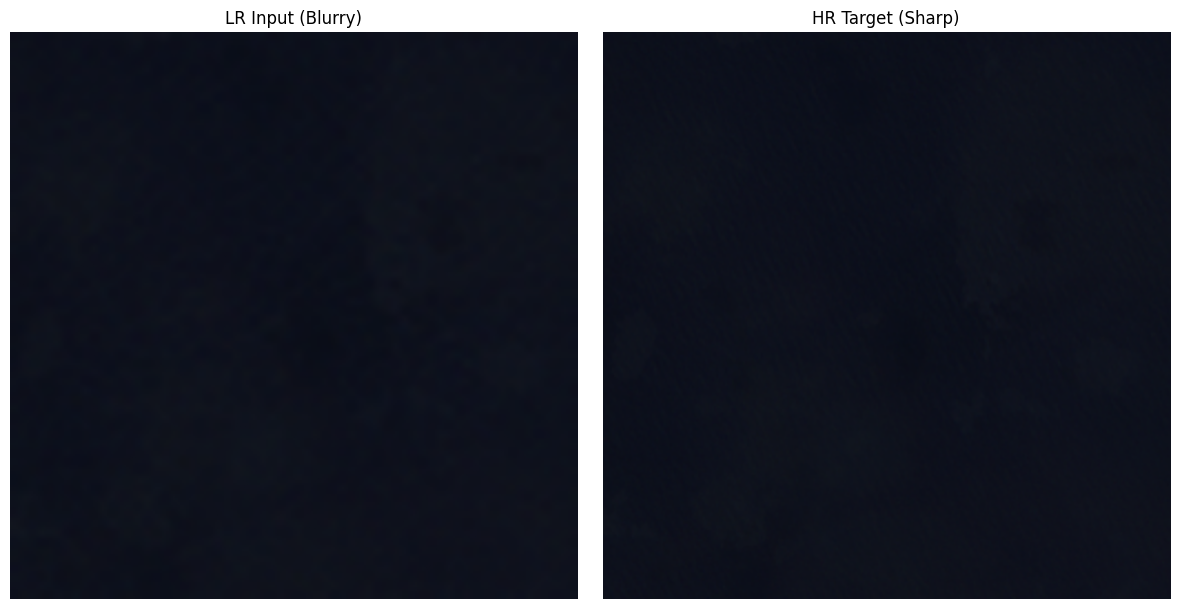

In [ ]:
# Save a sample for README
import matplotlib.pyplot as plt

lr_sample = lr_batch[0].permute(1, 2, 0).cpu().numpy()
hr_sample = hr_batch[0].permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.clip(lr_sample, 0, 1))
axes[0].set_title('LR Input (Blurry)')
axes[0].axis('off')

axes[1].imshow(np.clip(hr_sample, 0, 1))
axes[1].set_title('HR Target (Sharp)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../sample_lr_hr_pair.png', dpi=150, bbox_inches='tight')
print("💾 Saved sample to sample_lr_hr_pair.png")

# Task
Reinitialize the `train_loader` by re-running cell 1935b84b, then fetch a batch using cell 517fe170, and finally visualize the fetched batch with cell 24e0f2c6 to confirm the fix to the `dataset` module.

## Reinitialize DataLoader

### Subtask:
Re-run cell 1935b84b to re-create the `train_loader` object with the patched `dataset` module.


**Reasoning**:
To reinitialize the `train_loader` object with the patched `dataset` module, I need to re-execute the code in cell `1935b84b`.

